RNN

In [1]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence


class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, h_0=None):
        if h_0 is None:
            h_0 = torch.zeros(
                self.num_layers,
                x.size(0),
                self.hidden_size,
                device=x.device
            )
        out, h_n = self.rnn(x, h_0)
        output = self.fc(out)
        return output, h_n


data = [torch.randn(5, 10), torch.randn(3, 10), torch.randn(7, 10)]
lengths = [5, 3, 7]

padded_seq = torch.nn.utils.rnn.pad_sequence(data, batch_first=True)
print(f"Padded sequence shape: {padded_seq.shape}")

packed_seq = pack_padded_sequence(
    padded_seq,
    lengths,
    batch_first=True,
    enforce_sorted=False
)
print(f"Packed sequence: {packed_seq}")

input_size = 10
hidden_size = 20
rnn = nn.RNN(input_size, hidden_size, batch_first=True)

output, hidden = rnn(packed_seq)
print(f"Output of RNN with packed sequence: {output}")

unpacked_output, unpacked_lengths = pad_packed_sequence(output, batch_first=True)
print(f"Unpacked output shape: {unpacked_output.shape}")
print(f"Unpacked lengths: {unpacked_lengths}")

Padded sequence shape: torch.Size([3, 7, 10])
Packed sequence: PackedSequence(data=tensor([[-0.7041, -1.4702, -0.4401, -0.2920, -0.9126, -0.2078,  0.8319,  1.3107,
          2.4524,  0.2777],
        [ 0.9290,  0.7591, -0.2539,  0.3774, -0.2788, -0.5377,  1.4467,  0.0080,
         -1.1950,  0.0578],
        [-1.7932, -1.0788,  0.6316,  0.8855, -1.3222, -0.6039, -0.9807,  0.3018,
         -0.9947,  0.5418],
        [ 0.6681, -0.1989, -1.8253, -0.8643,  1.7217, -0.1978, -1.8204,  0.8448,
         -0.2186, -0.2234],
        [ 0.1258, -0.6646, -0.0681, -1.1926, -1.5440, -0.3174, -0.9030, -1.3379,
          0.6482, -0.1250],
        [-0.1811, -0.4600,  0.4781, -1.4896,  0.6012,  0.8420,  1.3272,  1.6287,
          0.6309, -0.2198],
        [-1.1912,  0.3529,  0.5977,  0.0286, -0.4211,  0.1860, -0.6896, -0.4185,
         -1.6158,  0.7392],
        [-0.6276,  0.2188, -1.6228,  1.5171,  0.3740, -0.8976, -0.0694, -0.9595,
         -0.1555, -0.5013],
        [ 0.1127,  0.9444, -0.4245, -1.3555, 

LSTM

In [2]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1, dropout=0):
        super(LSTMModel, self).__init__()
        # LSTM 계층: 드롭아웃 설정 포함 
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, 
                            num_layers=num_layers, batch_first=True, 
                            dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(x, hidden)
        
        # PackedSequence 입력 시 다시 텐서로 풀어주는 로직 
        if isinstance(out, torch.nn.utils.rnn.PackedSequence):
            out, _ = pad_packed_sequence(out, batch_first=True)
            
        out = self.dropout(out)
        output = self.fc(out)
        return output, hidden

시계열 데이터 전처리

In [3]:
import torch
import numpy as np
from sklearn.preprocessing import MinMaxScaler


if 'data' in globals() and isinstance(data, list) and all(isinstance(item, torch.Tensor) for item in data):
    padded_data = torch.nn.utils.rnn.pad_sequence(data, batch_first=True)
    data_concatenated = padded_data.view(-1, padded_data.shape[-1]).numpy()
elif 'data' in globals() and isinstance(data, np.ndarray):
    data_concatenated = data
else:
    print("Warning: 'data' variable not found or in unexpected format. Using dummy data.")
    data_concatenated = np.random.randn(100, 10)

scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data_concatenated)


def create_windows(data, window_size, horizon=1):
    x_list, y_list = [], []
    for i in range(len(data) - window_size - horizon + 1):
        x_list.append(data[i : (i + window_size)])
        y_list.append(data[i + window_size + horizon - 1])
    return np.array(x_list), np.array(y_list)


window_size = 10
horizon = 1

x_data, y_data = create_windows(data_normalized, window_size, horizon)

split_idx = int(len(x_data) * 0.8)
x_train, x_test = x_data[:split_idx], x_data[split_idx:]
y_train, y_test = y_data[:split_idx], y_data[split_idx:]

print(f"정규화된 데이터 크기: {len(data_normalized)}")
print(f"윈도우 데이터 크기: X = {x_data.shape}, y = {y_data.shape}")
print(f"훈련 데이터: X_train = {x_train.shape}, y_train = {y_train.shape}")
print(f"테스트 데이터: X_test = {x_test.shape}, y_test = {y_test.shape}")

정규화된 데이터 크기: 21
윈도우 데이터 크기: X = (11, 10, 10), y = (11, 10)
훈련 데이터: X_train = (8, 10, 10), y_train = (8, 10)
테스트 데이터: X_test = (3, 10, 10), y_test = (3, 10)


LSTM을 사용한 주식 가격 예측 모델

[*********************100%***********************]  1 of 1 completed


Epoch [1/100], Train Loss: 0.3146, Val Loss: 0.0841
Epoch [2/100], Train Loss: 0.0625, Val Loss: 0.2160
Epoch [3/100], Train Loss: 0.0281, Val Loss: 0.0024
Epoch [4/100], Train Loss: 0.0047, Val Loss: 0.0145
Epoch [5/100], Train Loss: 0.0101, Val Loss: 0.0181
Epoch [6/100], Train Loss: 0.0055, Val Loss: 0.0042
Epoch [7/100], Train Loss: 0.0026, Val Loss: 0.0057
Epoch [8/100], Train Loss: 0.0012, Val Loss: 0.0010
Epoch [9/100], Train Loss: 0.0017, Val Loss: 0.0020
Epoch [10/100], Train Loss: 0.0013, Val Loss: 0.0029
Epoch [11/100], Train Loss: 0.0016, Val Loss: 0.0028
Epoch [12/100], Train Loss: 0.0010, Val Loss: 0.0024
Epoch [13/100], Train Loss: 0.0011, Val Loss: 0.0010
Epoch [14/100], Train Loss: 0.0024, Val Loss: 0.0045
Epoch [15/100], Train Loss: 0.0014, Val Loss: 0.0027
Epoch [16/100], Train Loss: 0.0023, Val Loss: 0.0055
Epoch [17/100], Train Loss: 0.0012, Val Loss: 0.0009
Epoch [18/100], Train Loss: 0.0013, Val Loss: 0.0024
Epoch [19/100], Train Loss: 0.0009, Val Loss: 0.0016
Ep

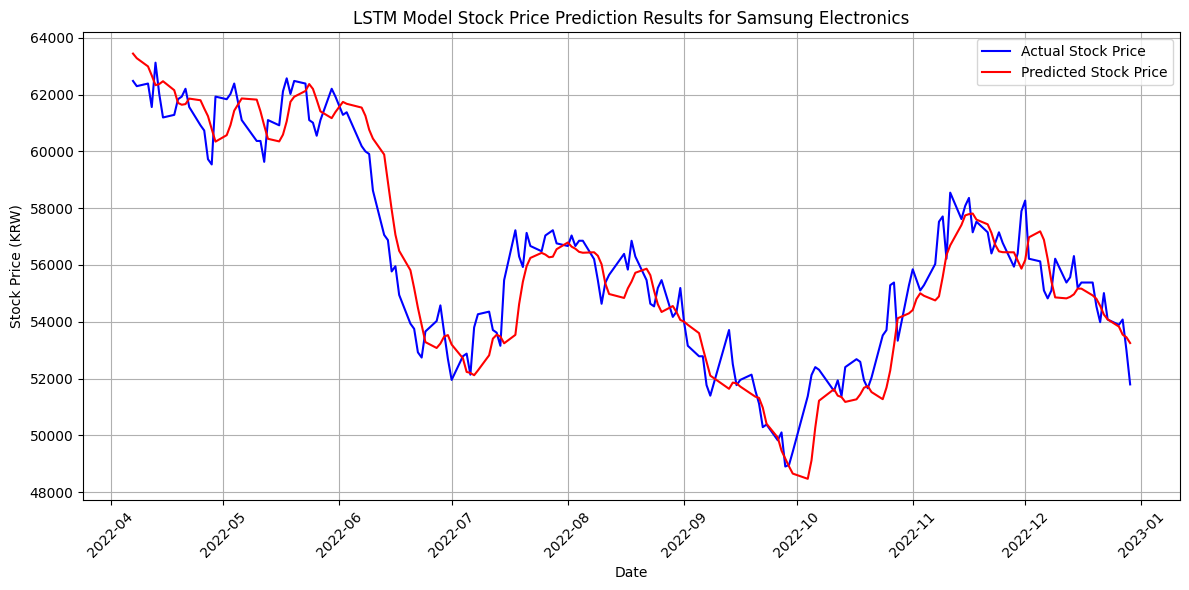

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 랜덤 시드 설정
torch.manual_seed(42)
np.random.seed(42)

# 주식 데이터 다운로드
ticker = "005930.KS"
start_date = "2018-01-01"
end_date = "2023-01-01"
stock_data = yf.download(ticker, start=start_date, end=end_date)

# 필요한 특성 선택 및 결측치 처리
df = stock_data[['Open', 'High', 'Low', 'Close', 'Volume']]
df = df.dropna()

# 데이터 정규화
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns,
    index=df.index
)


# 시계열 윈도우 생성 함수
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data.iloc[i : (i + seq_length)].values
        y = data.iloc[i + seq_length]['Close']
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys).reshape(-1, 1)


seq_length = 20
X, y = create_sequences(df_scaled, seq_length)

# 훈련/검증/테스트 분할
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = (
    X[train_size : train_size + val_size],
    y[train_size : train_size + val_size]
)
X_test, y_test = X[train_size + val_size :], y[train_size + val_size :]

# 파이토치 텐서로 변환
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)


class StockPredictionModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, dropout=0.2):
        super(StockPredictionModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_time_step = lstm_out[:, -1, :]
        out = self.dropout(last_time_step)
        predictions = self.fc(out)
        return predictions


# 모델 초기화
input_size = X_train.shape[2]
hidden_size = 64
num_layers = 2
model = StockPredictionModel(input_size, hidden_size, num_layers)

# 손실 함수 및 옵티마이저
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 모델 훈련
num_epochs = 100
batch_size = 32
train_losses = []
val_losses = []
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    for i in range(0, len(X_train), batch_size):
        batch_X = X_train[i : i + batch_size]
        batch_y = y_train[i : i + batch_size]

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

    model.eval()
    with torch.no_grad():
        train_preds = model(X_train)
        train_loss = criterion(train_preds, y_train).item()
        train_losses.append(train_loss)

        val_preds = model(X_val)
        val_loss = criterion(val_preds, y_val).item()
        val_losses.append(val_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_stock_model.pth')

# 최적 모델 불러오기 및 테스트
model.load_state_dict(torch.load('best_stock_model.pth'))
model.eval()

with torch.no_grad():
    test_predictions = model(X_test)

test_dates = df.index[train_size + val_size + seq_length:]


# 역정규화 함수
def inverse_transform_close(data):
    dummy = np.zeros((len(data), 5))
    dummy[:, 3] = data.flatten()  # Close 위치인 인덱스 3에 삽입
    return scaler.inverse_transform(dummy)[:, 3]


y_test_orig = inverse_transform_close(y_test.numpy())
test_predictions_orig = inverse_transform_close(test_predictions.numpy())

# 성능 지표 계산
mse = mean_squared_error(y_test_orig, test_predictions_orig)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_orig, test_predictions_orig)
r2 = r2_score(y_test_orig, test_predictions_orig)

print(f'테스트 MSE: {mse:.2f}')
print(f'테스트 RMSE: {rmse:.2f}')
print(f'테스트 MAE: {mae:.2f}')
print(f'테스트 R2: {r2:.4f}')

# 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(test_dates, y_test_orig, 'b-', label='Actual Stock Price')
plt.plot(test_dates, test_predictions_orig, 'r-', label='Predicted Stock Price')
plt.xlabel('Date')
plt.ylabel('Stock Price (KRW)')
plt.title('LSTM Model Stock Price Prediction Results for Samsung Electronics')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()